In [1]:
from astropy.io import ascii, fits
from astropy.table import Table
from run_prospector_new2 import *
from prospect.io import read_results as pread
import pandas as pd
import corner
import matplotlib.pyplot as plt
import numpy as np
import plotfancy as pf
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm
pf.housestyle_rcparams()

True

In [2]:
TAB = Table(ascii.read('sedrun.csv'))
TAB.add_index('object_id')
ROW = TAB[0]
FILE = 'out/224d52m16pt41356234s-18d10m42pt80767292sresults_3.h5'
# FILE = 'out/peas/88d19m48pt8284935s-33d42m42pt89990813sresults_0.h5'
# ROW = TAB.loc['88d19m48pt8284935s-33d42m42pt89990813s']

model = build_model(ROW)
model_params = model.theta_labels()
# from run_prosp_nonparaSFH import build_model, build_sps
results, observations_dict, _ = pread.results_from(FILE)
sps = pread.get_sps(results)
weights = results.get('weights',None) #likelihood values

building model


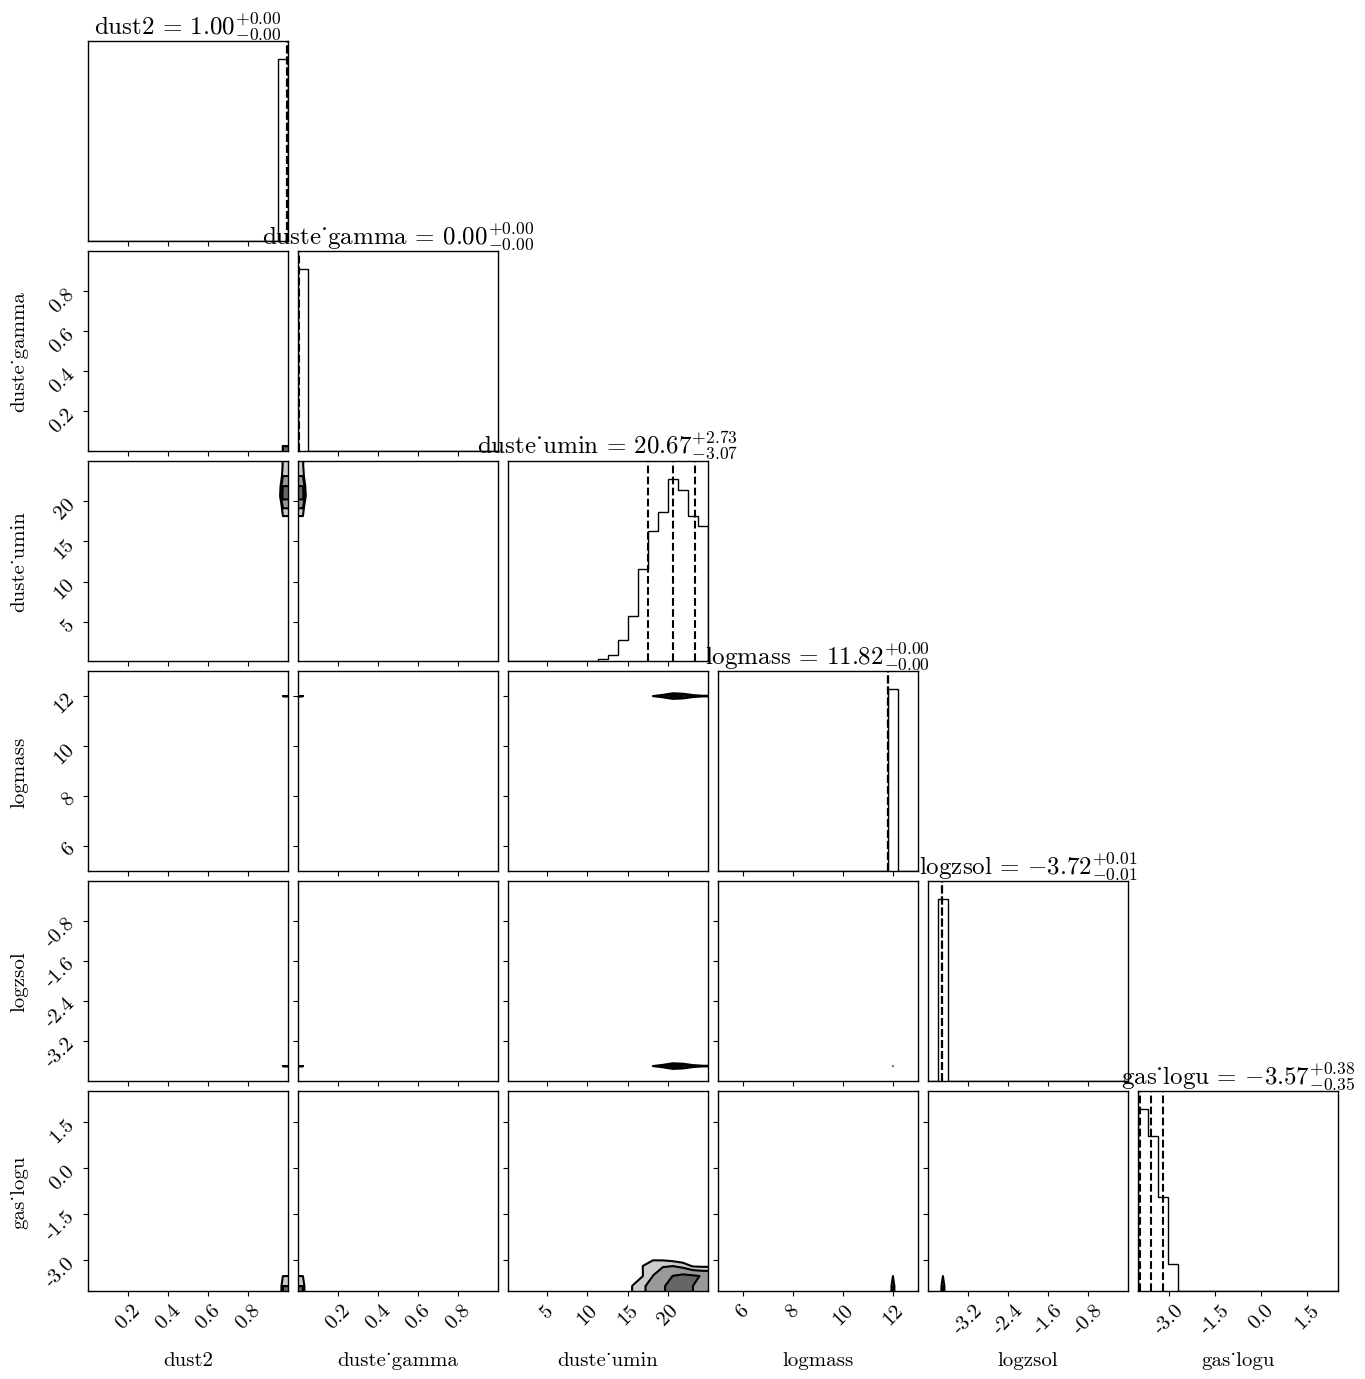

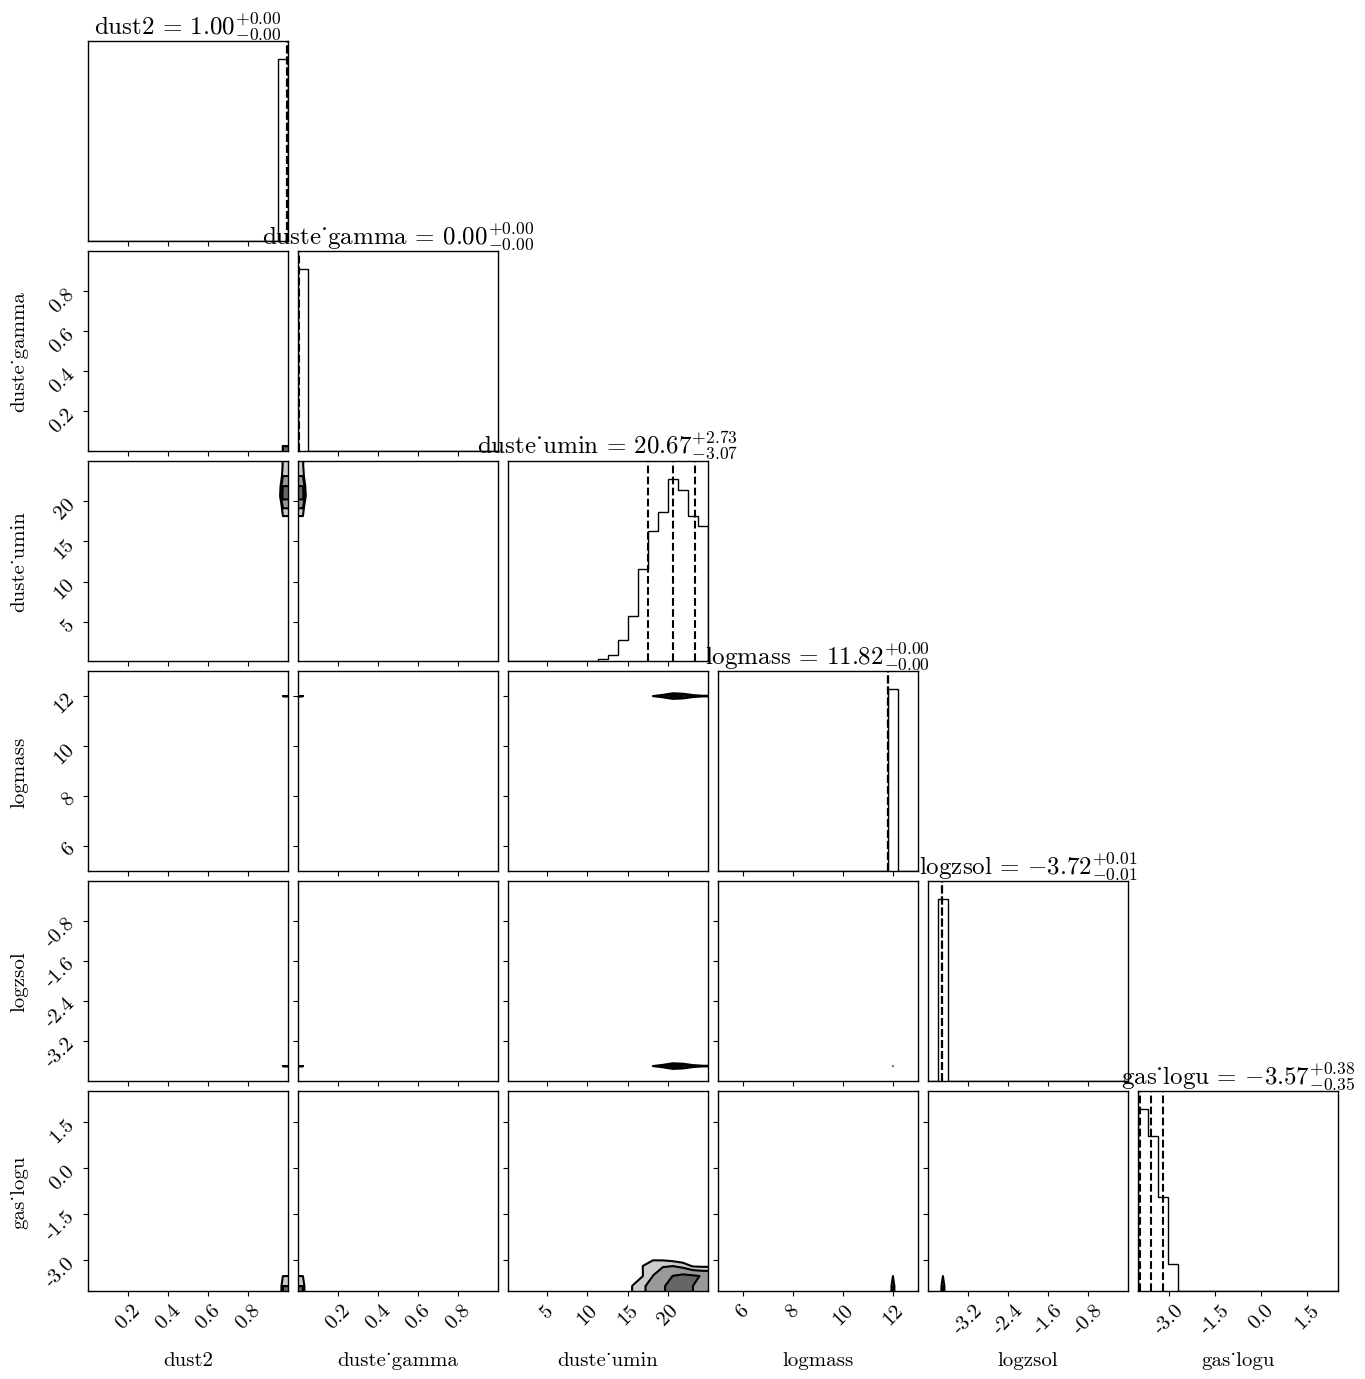

In [3]:
pread.subcorner(results, showpars=['dust2','duste_gamma','duste_umin','logmass','logzsol','gas_logu'])

In [4]:
def get_stellar_mass(res, obs, model, sps, percentiles=[16, 50, 84], nsample=5000):
    
    theta_labels = res.get('theta_labels', model.theta_labels())
    chain = res['chain']
    weights = res.get('weights', None)
    nsamples = chain.shape[0]

    # subsample using dynesty weights so the subset is still representative
    if nsamples > nsample:
        weights_norm = weights / weights.sum()
        idx = np.random.choice(nsamples, size=nsample, replace=False, p=weights_norm)
        chain = chain[idx]
        weights = None  # already accounted for in the sampling, use uniform after
        nsamples = nsample

    logmass_idx = theta_labels.index('logmass')
    stellar_masses = np.zeros(nsamples)

    for ii in tqdm(range(nsamples)):
        theta = chain[ii]
        spec, phot, mfrac = model.predict(theta, obs=obs, sps=sps)
        logmass = chain[ii, logmass_idx]
        stellar_masses[ii] = (10**logmass) * mfrac
        
        # if ii % 500 == 0:
        #     print(f'  {ii}/{nsamples} samples done')

    def weighted_quantile(values, quantiles, weights):
        sorter = np.argsort(values)
        values = values[sorter]
        weights = weights[sorter]
        cumsum = np.cumsum(weights)
        cumsum /= cumsum[-1]
        return np.interp(quantiles, cumsum, values)

    if weights is not None:
        mass_percentiles = weighted_quantile(
            stellar_masses, np.array(percentiles)/100., weights
        )
    else:
        mass_percentiles = np.percentile(stellar_masses, percentiles)

    return stellar_masses, mass_percentiles


In [5]:

stellar_masses, mass_percentiles = get_stellar_mass(results, observations_dict, model, sps=sps)

100%|██████████| 5000/5000 [01:14<00:00, 66.87it/s]


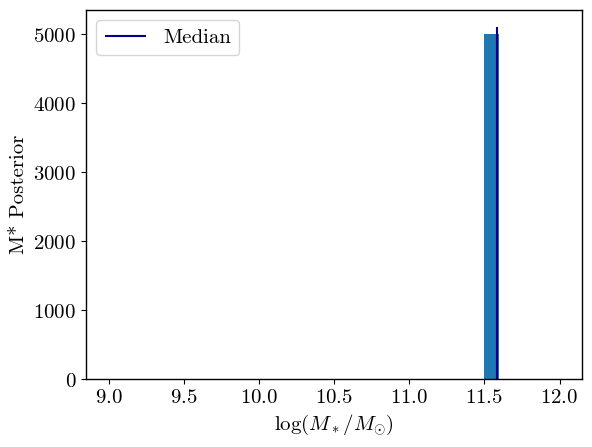

In [6]:
import matplotlib.pyplot as plt
n = plt.hist(np.log10(stellar_masses), range=(9, 12), bins=30)
plt.vlines(np.median(np.log10(stellar_masses)), ymin=0, ymax=np.max(n[0])+100, color='darkblue', label='Median')
plt.ylabel('M* Posterior')
plt.xlabel('$\log(M_* / M_{\odot})$')
plt.legend()

In [7]:
# from prospect.models import transforms
# def get_sfr(res, mod):
#     agebins = mod.params['agebins']
#     thetas = mod.theta_labels()                                                                                                                                           
#     agebins_yrs = 10**agebins.T
#     dt = agebins_yrs[1, :] - agebins_yrs[0, :]
#     zfrac_idx = [i for i, s in enumerate(thetas) if 'z_fraction' in s]
#     zfrac_chain = res['chain'][:,zfrac_idx[0]:zfrac_idx[-1]+1]
    
#     total_mass_chain = res['chain'][:,thetas.index('logmass')]
#     sfr_chain = []
#     weights = results.get('weights',None) #likelihood values
#     idx = np.argsort(weights)[-5000:]
#     for i in idx:
#         #this is the important part of this function -- it takes the proxy model parameters we sampled
#         # and transforms them into the masses formed in each timebin
#         # from there, we just divide these masses by the time in each bin to get the SFR in each bin
#         masses_chain = transforms.zfrac_to_masses(10**total_mass_chain[i], zfrac_chain[i], agebins)
#         sfr = masses_chain / dt                                                                                                                                  
#         sfr_chain.append(sfr[0])                                                                                                                                                
#     return sfr_chain



In [8]:
def get_sfr(res, model, agebins=None, percentiles=[16, 50, 84]):
    """
    Compute the SFR posterior from prospector results.

    Parameters
    ----------
    res : dict
        The results dictionary from prospect (loaded via reader.results_from).
    model : SedModel
        The prospector model object.
    agebins : np.ndarray, optional
        Shape (nbin, 2) array of log(yr) age bin edges.
        If None, pulled from model_params.
    percentiles : list
        Percentiles to return for summary statistics.

    Returns
    -------
    sfr_samples : np.ndarray, shape (nsamples, nbin)
        SFR in Msun/yr for each posterior sample and age bin.
    sfr_percentiles : np.ndarray, shape (len(percentiles), nbin)
        Requested percentiles of the SFR in each bin.
    bin_centers : np.ndarray, shape (nbin,)
        Central lookback time of each bin in Gyr (for plotting).
    agebins : np.ndarray, shape (nbin, 2)
        The age bin edges in log(yr) used.
    """
    import numpy as np

    # --- 1. Pull posterior samples ---
    theta_labels = res.get('theta_labels', model.theta_labels())
    chain = res['chain']                     # (nsamples, nparams)
    weights = res.get('weights', None)

    # --- 2. Recover agebins ---
    if agebins is None:
        parnames = [p['name'] for p in model.config_list]
        agebins = model.config_list[parnames.index('agebins')]['init']
    agebins = np.atleast_2d(agebins)
    nbin = agebins.shape[0]

    # Time spent in each bin, in years
    dt = np.diff(10**agebins, axis=-1)[:, 0]   # (nbin,) [yr]

    # --- 3. Find parameter indices in the chain ---
    logmass_idx = theta_labels.index('logmass')

    # Handle both 'logsfr_ratios' (single vector column) and
    # 'logsfr_ratios_0', 'logsfr_ratios_1', ... (expanded columns)
    sfr_ratio_idxs = [i for i, l in enumerate(theta_labels)
                      if l == 'logsfr_ratios' or l.startswith('logsfr_ratios_')]

    if len(sfr_ratio_idxs) == 1:
        # Stored as a single vector column — already a (nbin-1,) array
        idx = sfr_ratio_idxs[0]
        get_logsfr_ratios = lambda row: row[idx]
    else:
        assert len(sfr_ratio_idxs) == nbin - 1, (
            f"Expected {nbin-1} logsfr_ratio columns, found {len(sfr_ratio_idxs)}"
        )
        get_logsfr_ratios = lambda row: row[sfr_ratio_idxs]

    # --- 4. Reconstruct masses (and SFRs) for every sample ---
    nsamples = chain.shape[0]
    sfr_samples = np.zeros((nsamples, nbin))

    for ii in range(nsamples):
        logmass       = chain[ii, logmass_idx]
        logsfr_ratios = get_logsfr_ratios(chain[ii])

        masses = logsfr_ratios_to_masses(
            logmass=logmass,
            logsfr_ratios=logsfr_ratios,
            agebins=agebins,
        )
        sfr_samples[ii] = masses / dt

    # --- 5. Summary percentiles (weighted if dynesty) ---
    if weights is not None:
        # weighted percentile via cumulative weight sorting
        def weighted_quantile(values, quantiles, weights):
            sorter = np.argsort(values)
            values = values[sorter]
            weights = weights[sorter]
            cumsum = np.cumsum(weights)
            cumsum /= cumsum[-1]
            return np.interp(quantiles, cumsum, values)

        sfr_percentiles = np.array([
            weighted_quantile(sfr_samples[:, bb], np.array(percentiles)/100., weights)
            for bb in range(nbin)
        ]).T
    else:
        sfr_percentiles = np.percentile(sfr_samples, percentiles, axis=0)

    # --- 6. Bin-centre lookback times in Gyr ---
    bin_centers = 10 ** (0.5 * (agebins[:, 0] + agebins[:, 1])) / 1e9  # Gyr

    return sfr_samples, sfr_percentiles, bin_centers, agebins

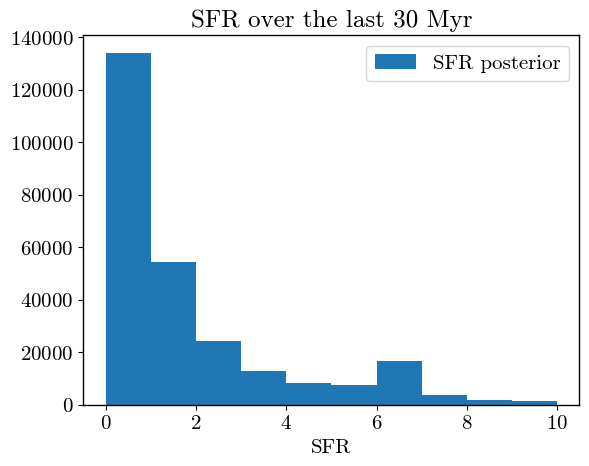

In [9]:
#now plot model SFR histogram
model_sfr,_,_,_ = get_sfr(results, model)
n, _, _, = plt.hist(model_sfr.flatten(), range=(0,10), label='SFR posterior')
plt.title('SFR over the last 30 Myr')
plt.xlabel('SFR')
plt.legend()

agebins shape: (8, 2)


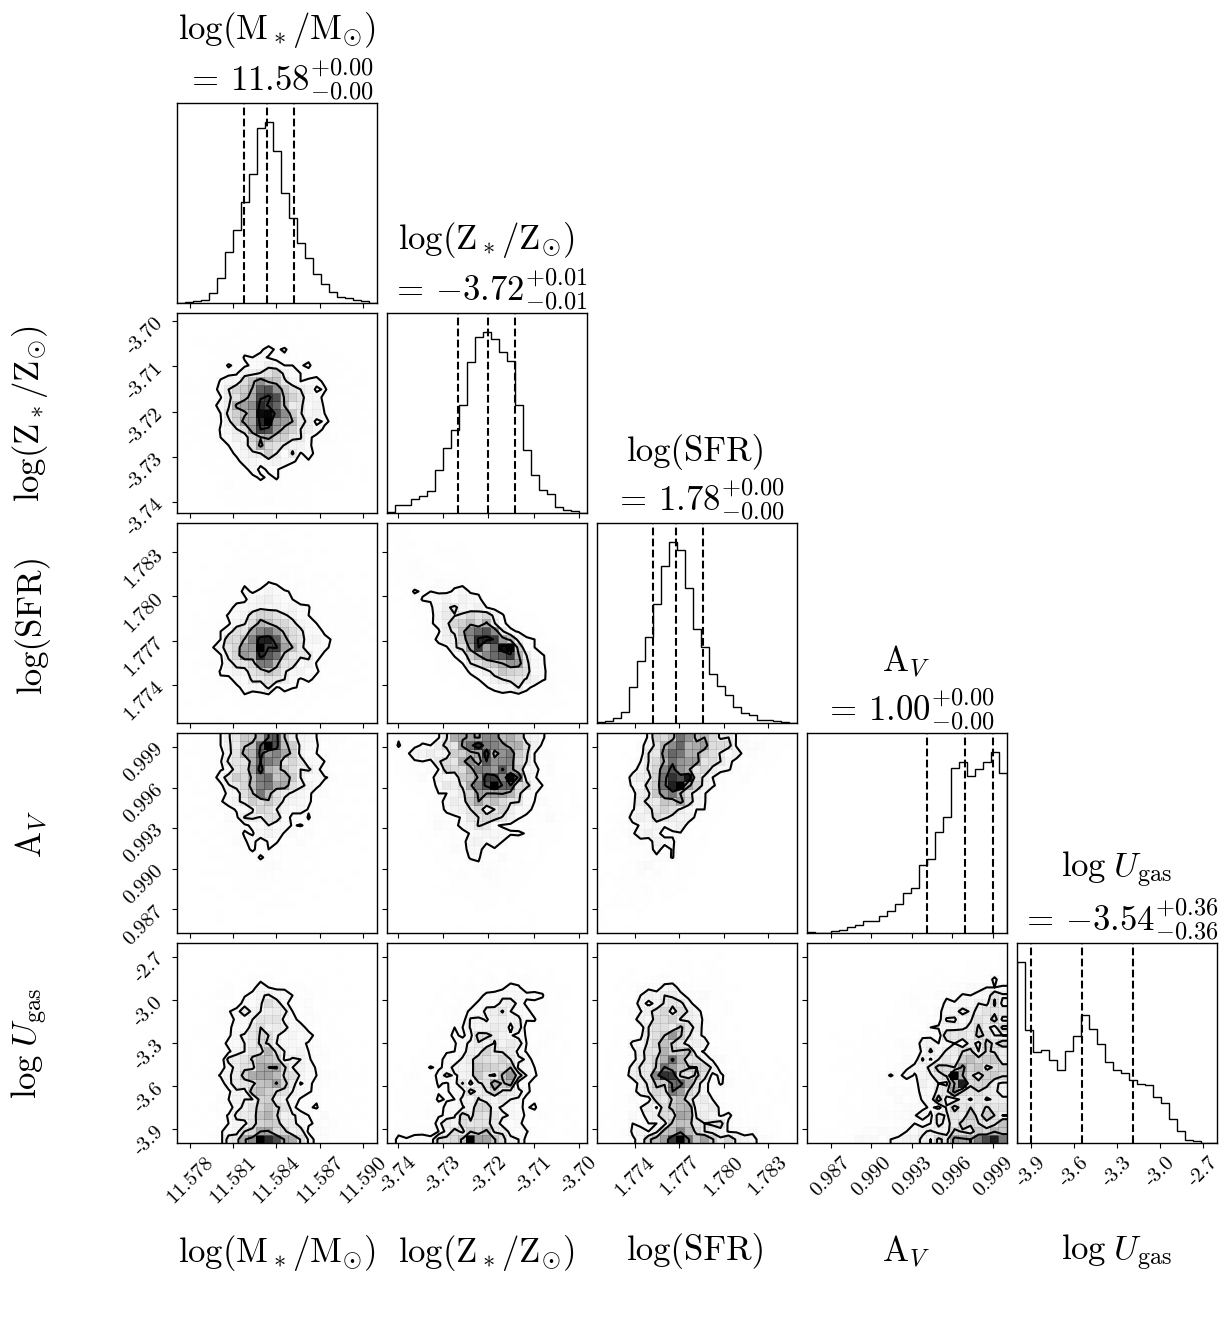

In [10]:
# model_params_names = [m.get('name') for m in model_params]
model_params_names = model.theta_labels()
model_params_names.index('logzsol')
idx = np.argsort(weights)[-5000:] 

parnames = [p['name'] for p in model.config_list]
agebins = np.array(model.config_list[parnames.index('agebins')]['init'])
print("agebins shape:", agebins.shape)  # should be (8, 2)

sfr_samples_top = model_sfr[idx, :]
dt = np.diff(10**agebins, axis=-1)[:, 0]  # bin widths in yr, shape (nbin,)
total_sfr = np.sum(sfr_samples_top * dt, axis=1) / np.sum(dt)  # shape (5000,)
log_sfr = np.log10(total_sfr)

data = {'log(M$_*$/M$_{\odot}$)\n': np.log10(stellar_masses),
       'log(Z$_*$/Z$_{\odot}$)\n': results['chain'][idx,model_params_names.index('logzsol')],
       'log(SFR)\n': log_sfr,
       'A$_V$\n': results['chain'][idx,model_params_names.index('dust2')],
#        '$\log\;\gamma_j$': np.log10(results['chain'][idx,model_params_names.index('duste_gamma')]),
        'log$\;U_{\mathrm{gas}}$\n': results['chain'][idx,model_params_names.index('gas_logu')],
}
        
df = pd.DataFrame(data)


figure = corner.corner(df,labels=list(data.keys()),
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=True, title_kwargs={"fontsize": 25}, label_kwargs={'fontsize': 25}, labelpad=0.15,
                      bins=25,plot_datapoints=False)


In [11]:
def get_spec_posterior(res, obs, model, sps, nsample=10000, percentiles=[16, 50, 84]):
    """
    Returns the spectrum posterior in units of maggies.
    """
    theta_labels = res.get('theta_labels', model.theta_labels())
    chain = res['chain']
    weights = res.get('weights', None)
    nsamples = chain.shape[0]

    # draw representative samples using dynesty weights
    if weights is not None:
        weights_norm = weights / weights.sum()
        idx = np.random.choice(nsamples, size=nsample, replace=False, p=weights_norm)
    else:
        idx = np.random.choice(nsamples, size=nsample, replace=False)

    spec_samples = []
    for ii, i in tqdm(enumerate(idx)):
        theta = chain[i]
        spec, phot, mfrac = model.predict(theta, obs=obs, sps=sps)
        spec_samples.append(spec)
        # if ii % 50 == 0:
        #     print(f'  {ii}/{nsample} done')

    spec_samples = np.array(spec_samples)  # (nsample, nwave)

    spec_lo  = np.percentile(spec_samples, percentiles[0], axis=0)
    spec_mid = np.percentile(spec_samples, percentiles[1], axis=0)
    spec_hi  = np.percentile(spec_samples, percentiles[2], axis=0)
    
    # wavelength array is stored in obs
    wavelength = obs['wavelength']  # in Angstroms, observed frame

    return wavelength, spec_lo, spec_mid, spec_hi, spec_samples

def get_ir_spec_posterior(res, obs, model, sps, nsample=200,
                          ir_wave_um=None, percentiles=[16, 50, 84]):
    """
    Returns posterior spectrum samples over an IR wavelength grid.

    Parameters
    ----------
    ir_wave_um : array-like, optional
        Wavelengths in microns. Defaults to 200 points from 3 to 5 µm,
        covering the IRAC 3.6 and 4.5 µm bands.

    Returns
    -------
    ir_wave_um   : 1-D array, wavelengths in microns
    ir_spec_lo   : 1-D array, 16th percentile in maggies
    ir_spec_mid  : 1-D array, 50th percentile in maggies
    ir_spec_hi   : 1-D array, 84th percentile in maggies
    spec_samples : 2-D array, shape (nsample, nwave), in maggies
    """
    if ir_wave_um is None:
        ir_wave_um = np.linspace(3.0, 5.0, 200)

    # obs dict for IR: wavelength in Angstroms (observed frame), no mask needed
    zred = float(model.params['zred'])
    ir_wave_aa = ir_wave_um * 1e4  # µm → Å

    obs_ir = {
        'wavelength': ir_wave_aa,
        'spectrum':   np.ones_like(ir_wave_aa),   # placeholder, not used
        'unc':        np.ones_like(ir_wave_aa),   # placeholder
        'mask':       np.ones(len(ir_wave_aa), dtype=bool),
        'filters':    obs.get('filters', None),   # keep photometry filters
        'maggies':    obs.get('maggies', None),
        'maggies_unc':obs.get('maggies_unc', None),
    }

    chain   = res['chain']
    weights = res.get('weights', None)
    nsamples = chain.shape[0]

    if weights is not None:
        weights_norm = weights / weights.sum()
        idx = np.random.choice(nsamples, size=nsample, replace=False, p=weights_norm)
    else:
        idx = np.random.choice(nsamples, size=nsample, replace=False)

    spec_samples = []
    for ii, i in tqdm(enumerate(idx)):
        theta = chain[i]
        spec, phot, mfrac = model.predict(theta, obs=obs_ir, sps=sps)
        spec_samples.append(spec)
        # if ii % 50 == 0:
        #     print(f'  {ii}/{nsample} done')

    spec_samples = np.array(spec_samples)   # (nsample, nwave)

    ir_spec_lo  = np.percentile(spec_samples, percentiles[0], axis=0)
    ir_spec_mid = np.percentile(spec_samples, percentiles[1], axis=0)
    ir_spec_hi  = np.percentile(spec_samples, percentiles[2], axis=0)

    return ir_wave_um, ir_spec_lo, ir_spec_mid, ir_spec_hi, spec_samples

In [12]:
wavelength, spec_lo, spec_mid, spec_hi, spec_samples = get_spec_posterior(
    results, observations_dict, model, sps, nsample=200
)

ir_wave, ir_spec_lo, ir_spec_mid, ir_spec_hi, spec_samples_ir = get_ir_spec_posterior(
    results, observations_dict, model, sps, nsample=200
)

200it [00:02, 76.49it/s]
/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_11605/1697000816.py:59: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zred = float(model.params['zred'])
200it [00:02, 74.98it/s]


In [13]:
chain = results.get('chain', None)
lnprobability = results.get('lnprobability', None)
flat_lnprobability = lnprobability.reshape(-1)
flat_chain = chain.reshape(-1, chain.shape[-1])
best_fit_index = np.argmax(flat_lnprobability)
bestfit_params = flat_chain[best_fit_index]

In [14]:
# mod_obs = observations_dict.copy()
mod_obs = {}
mod_obs['filters'] = observations_dict['filters']
mod_obs['wavelength'] = np.arange(4750,50000,2.5)
spec,phot,extras = model.predict(bestfit_params, sps=sps,obs=mod_obs)

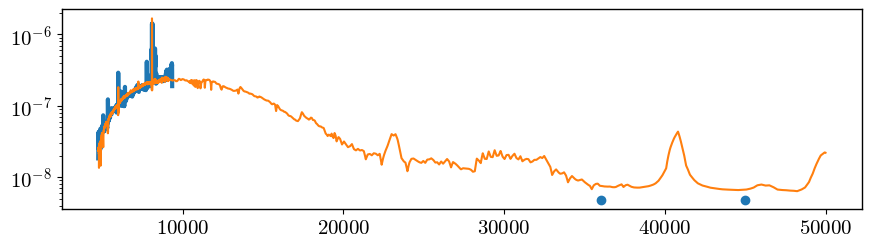

In [15]:
fig, ax = pf.create_plot([8,2])
ax.plot(observations_dict['wavelength'],observations_dict['spectrum'], lw=3)
ax.plot(mod_obs['wavelength'],spec)
ax.scatter([36000,45000],observations_dict['maggies'])

ax.set_yscale('log')


In [16]:
def plot_sfh_step_continuous(ax, agebins, sfh_lo, sfh_hi, sfh_med):
    """
    Plots star formation history as a continuous step plot, correctly
    handling non-contiguous bins.

    This version builds the coordinate arrays for plotting and explicitly
    inserts `np.nan` where gaps between bins occur. This prevents matplotlib
    from drawing incorrect connecting lines across those gaps.

    Parameters:
    - ax: The matplotlib axes object to plot on.
    - agebins: An array of shape (N, 2) defining the age bins in Gyr.
    - sfh_lo: The lower uncertainty of the SFH for each bin.
    - sfh_hi: The upper uncertainty of the SFH for each bin.
    - sfh_med: The median SFH for each bin.
    """
    bin_lo_gyr = agebins[:, 0]
    bin_hi_gyr = agebins[:, 1]

    # Create coordinate arrays for a continuous step plot.
    # We start by creating the coordinates as if all bins were contiguous.
    # x will be [bin_lo_0, bin_hi_0, bin_lo_1, bin_hi_1, ...]
    # y will be [sfh_0,    sfh_0,    sfh_1,    sfh_1,    ...]
    x_coords = list(np.array([bin_lo_gyr, bin_hi_gyr]).T.flatten())
    y_med_coords = list(np.repeat(sfh_med, 2))
    y_lo_coords = list(np.repeat(sfh_lo, 2))
    y_hi_coords = list(np.repeat(sfh_hi, 2))

    # Now, iterate through the bins to find any gaps.
    # Where a gap exists, we insert a `NaN` to break the line plot.
    insert_offset = 0
    for i in range(agebins.shape[0] - 1):
        # Check if the end of the current bin matches the start of the next one
        if bin_hi_gyr[i] != bin_lo_gyr[i+1]:
            # If they don't match, there's a gap.
            # We need to insert a break after the points for the current bin.
            # The insertion index is after the two points of the current bin.
            insert_idx = 2 * (i + 1) + insert_offset
            
            x_coords.insert(insert_idx, np.nan)
            y_med_coords.insert(insert_idx, np.nan)
            y_lo_coords.insert(insert_idx, np.nan)
            y_hi_coords.insert(insert_idx, np.nan)
            
            # Increment the offset since we've added an element to the lists
            insert_offset += 1
    x_coords = 10**np.array(x_coords)/10**9

    # Plot the uncertainty range as a continuous filled area
    ax.fill_between(
        x_coords,
        y_lo_coords,
        y_hi_coords,
        alpha=0.3, color='#77aca2',
        label='68% Confidence Interval'
    )

    # Plot the median SFH as a continuous step line
    ax.plot(
        x_coords,
        y_med_coords,
        color='k',
        linewidth=3,
        label='Median SFH'
    )


/var/folders/6b/x84gj0ds47n3hjglw1wq1j8m0000gn/T/ipykernel_11605/3676763785.py:98: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  zred         = float(model.params['zred'])


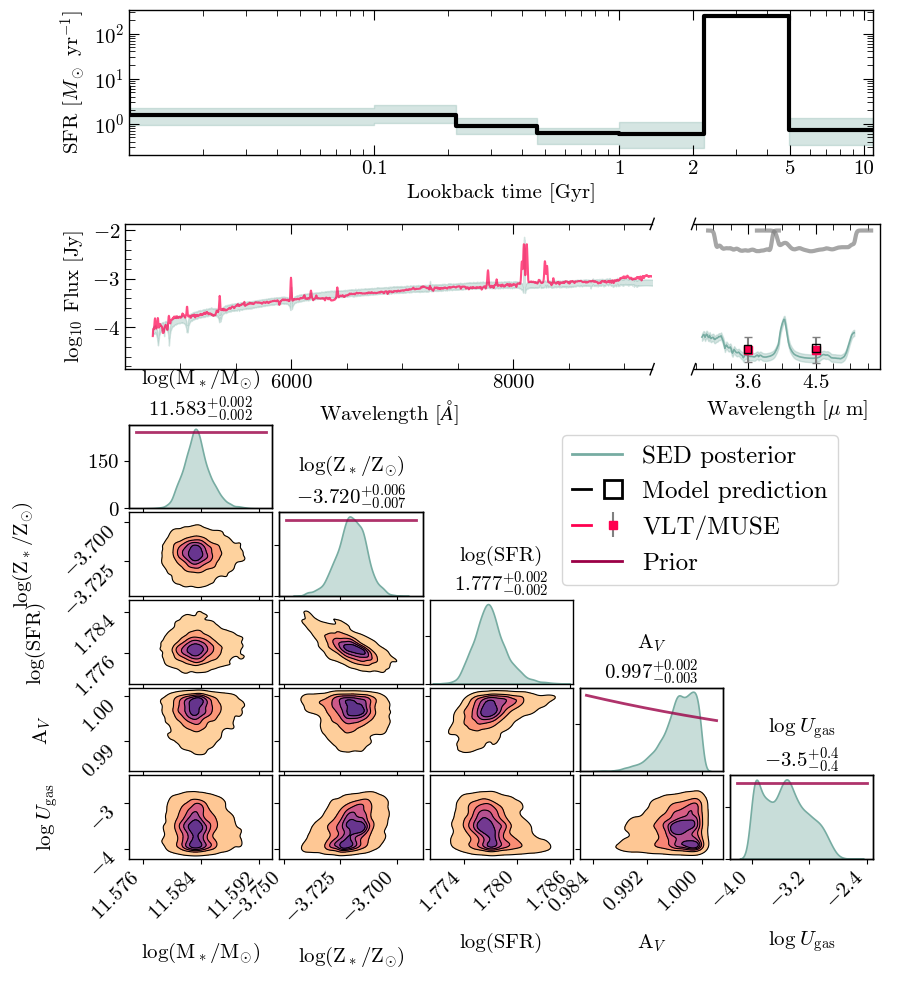

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import corner
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
from decimal import Decimal

FONTSIZE = 15
LABEL_NUDGE = 12

plt.rcParams.update({
    'font.size':        FONTSIZE,
    'axes.titlesize':   FONTSIZE,
    'axes.labelsize':   FONTSIZE,
    'xtick.labelsize':  FONTSIZE,
    'ytick.labelsize':  FONTSIZE,
    'legend.fontsize':  FONTSIZE,
})

# ---------------------------------------------------------------------------
# Utility: round x to the decimal place of the first significant figure of ref
# ---------------------------------------------------------------------------
def round_to_1sf_of(ref):
    """Return the number of decimal places needed to express ref to 1 s.f."""
    if ref == 0:
        return 0
    from math import floor, log10
    mag = floor(log10(abs(ref)))   # e.g. 0.0034 → mag = -3
    return max(0, -mag)            # decimal places needed

def format_title(val, low, high):
    """
    Round each error to 1 s.f., then round val to match the precision of
    whichever rounded error is more precise (i.e. more decimal places).
    """
    def round_err_to_1sf(e):
        if e == 0:
            return 0.0, 0
        from math import floor, log10
        mag   = floor(log10(abs(e)))
        scale = 10 ** mag
        rounded = round(e / scale) * scale   # 1 s.f.
        dp = max(0, -mag)
        return rounded, dp

    low_r,  dp_low  = round_err_to_1sf(low)
    high_r, dp_high = round_err_to_1sf(high)
    dp = max(dp_low, dp_high)          # use the finer of the two precisions

    val_r = round(val, dp)

    fmt = f'{{:.{dp}f}}'
    return f'${fmt.format(val_r)}^{{+{fmt.format(high_r)}}}_{{-{fmt.format(low_r)}}}$'


def add_break_markers(ax_left, ax_right, size=6, angle=70):
    import matplotlib.transforms as mtransforms

    dx = size * np.cos(np.radians(angle))
    dy = size * np.sin(np.radians(angle))

    for ax, x_ax in [(ax_left, 1.0), (ax_right, 0.0)]:
        for y_frac in [0.0, 1.0]:
            disp_pt = ax.transAxes.transform((x_ax, y_frac))
            x0_disp, y0_disp = disp_pt
            p1 = ax.transAxes.inverted().transform((x0_disp - dx, y0_disp - dy))
            p2 = ax.transAxes.inverted().transform((x0_disp + dx, y0_disp + dy))
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    transform=ax.transAxes,
                    color='k', linewidth=1, clip_on=False)


param_keys = ['logmass', 'logzsol', None, 'dust2', 'duste_gamma', 'gas_logu']
labels     = list(data.keys())
n_params   = len(data)
df         = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# Figure layout
# ---------------------------------------------------------------------------
fig     = plt.figure(figsize=(8.27, 9))
subfigs = fig.subfigures(3, 1, height_ratios=[2, 2, 5], hspace=0.09)

ax_sfh       = subfigs[0].add_subplot(1, 1, 1)
spec_subfigs = subfigs[1].subfigures(1, 2, width_ratios=[3, 1], wspace=0.0)
ax_spec_opt  = spec_subfigs[0].add_subplot(1, 1, 1)
ax_spec_ir   = spec_subfigs[1].add_subplot(1, 1, 1)

ax_spec_ir.sharey(ax_spec_opt)
ax_spec_ir.tick_params(labelleft=False)

# ---------------------------------------------------------------------------
# SFH panel
# ---------------------------------------------------------------------------
agebins      = model.params['agebins']
time_per_bin = np.diff(10**agebins, axis=-1)[:, 0]
zred         = float(model.params['zred'])
tuniv_gyr    = cosmo.age(zred).value

n_draw      = min(200, len(idx))
sfh_samples = []

for i in np.random.choice(idx, size=n_draw, replace=False):
    logmass        = results['chain'][i, model_params_names.index('logmass')]
    sfr_ratio_idxs = [k for k, l in enumerate(model_params_names) if l.startswith('logsfr_ratios')]
    logsfr_ratios  = results['chain'][i, sfr_ratio_idxs]
    masses         = logsfr_ratios_to_masses(
        logmass=logmass, logsfr_ratios=logsfr_ratios, agebins=agebins,
    )
    sfh_samples.append(masses / time_per_bin)

sfh_samples = np.array(sfh_samples)
sfh_lo      = np.percentile(sfh_samples, 16, axis=0)
sfh_med     = np.percentile(sfh_samples, 50, axis=0)
sfh_hi      = np.percentile(sfh_samples, 84, axis=0)

plot_sfh_step_continuous(ax_sfh, agebins, sfh_lo, sfh_hi, sfh_med)

ax_sfh.set_xlim(0, tuniv_gyr)
ax_sfh.set_yscale('log')
ax_sfh.set_xlabel('Lookback time [Gyr]')
ax_sfh.set_ylabel('SFR [$M_\odot$ yr$^{-1}$]')
ax_sfh.xaxis.set_major_locator(plt.MaxNLocator(3))
ax_sfh.set_xscale('log')
ax_sfh.set_xlim(left=10**agebins[1, 0] / 1e9)  # start from the second bin to avoid log(0)
ax_sfh.xaxis.set_major_locator(plt.FixedLocator([0.1,1, 2, 5, 10]))
ax_sfh.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:g}'))
ax_sfh.xaxis.set_minor_locator(plt.NullLocator())
ax_sfh.yaxis.set_major_locator(plt.LogLocator(numticks=3))

# ---------------------------------------------------------------------------
# Spectrum panel — optical
# ---------------------------------------------------------------------------
ax_spec_opt.set_xlim(4500, 9250)
ax_spec_opt.set_xlabel(r'Wavelength $[\AA]$')
ax_spec_opt.set_ylabel(r'$\log_{10}\;$Flux [Jy]')
ax_spec_opt.xaxis.set_major_locator(plt.MaxNLocator(3))
ax_spec_opt.yaxis.set_major_locator(plt.MaxNLocator(3))
ax_spec_opt.tick_params(labelsize=FONTSIZE)
ax_spec_opt.spines['right'].set_visible(False)
ax_spec_opt.tick_params(right=False)

# ---------------------------------------------------------------------------
# Spectrum panel — IR  (both photometry points AND posterior model spectrum)
# ---------------------------------------------------------------------------
# Expected external variables (you supply these, analogous to sfh_samples):
#   ir_wave        : 1-D array of wavelengths in microns covering IRAC bands
#   spec_samples_ir: 2-D array [n_draw, len(ir_wave)] of posterior model fluxes in maggies

irac_x      = [3.6, 4.5]
irac_labels = [r'$3.6$', r'$4.5$']

# ax_spec_ir.set_xlim(0, 3)
ax_spec_ir.set_xticks([])                   # will be set explicitly after plotting
ax_spec_ir.yaxis.set_major_locator(plt.MaxNLocator(3))
ax_spec_ir.tick_params(left=False, labelleft=False)
ax_spec_ir.spines['left'].set_visible(False)
ax_spec_ir.set_xlabel(r'Wavelength [$\mu\;\mathrm{m}$]')

# --- posterior model spectrum in IR band ---
ir_spec_lo  = np.percentile(spec_samples_ir, 16, axis=0)
ir_spec_med = np.percentile(spec_samples_ir, 50, axis=0)
ir_spec_hi  = np.percentile(spec_samples_ir, 84, axis=0)

ax_spec_ir.fill_between(
    ir_wave,
    0.98*np.log10(ir_spec_lo  * 3631),
    1.02*np.log10(ir_spec_hi  * 3631),
    alpha=0.3, color='#77aca2', zorder=1,
)
ax_spec_ir.plot(
    ir_wave,
    np.log10(ir_spec_med * 3631),
    color='#77aca2', linewidth=1.2, zorder=2,
)

# --- observed photometry on top ---
ax_spec_ir.errorbar(
    irac_x,
    np.log10(2*observations_dict['maggies'] * 3631),
    yerr=0.432 * observations_dict['maggies_unc'] * 6 / observations_dict['maggies'],
    fmt='s', color='#ff004f', capsize=3, ecolor='gray', zorder=5,
)

ax_spec_ir.scatter(
    irac_x,
    np.log10(phot * 3631), marker='s', edgecolor='k', facecolor='none', zorder=10, s=30)

# restore the micron tick labels after all plotting is done
ax_spec_ir.set_xticks(irac_x)
ax_spec_ir.set_xticklabels(irac_labels)
ax_spec_ir.xaxis.set_tick_params(length=4)

# --- optical observed spectrum + uncertainty envelope ---
ax_spec_opt.plot(
    observations_dict['wavelength'],
    np.log10(observations_dict['spectrum'] * 3631),
    color='#ff004f', linewidth=1.5, alpha=0.7, zorder=10,
)
ax_spec_opt.fill_between(
    observations_dict['wavelength'],
    0.98 * np.log10(spec_lo * 3631),
    1.02 * np.log10(spec_hi * 3631),
    alpha=0.3, color='#77aca2',
)

# ── Spitzer IRAC transmission curves ─────────────────────────────────────────
# expects filter_3p6 and filter_4p5 as (wavelength_um, transmission) tuples
# if loading from SVO .dat files:
filter_3p6 = np.loadtxt('filters/irac1.dat')  # cols: wavelength(AA), transmission
filter_4p5 = np.loadtxt('filters/irac2.dat')
y_top = ax_spec_ir.get_ylim()[1]
y_bot = ax_spec_ir.get_ylim()[0]
for filt_data, color in [(filter_3p6, 'gray'), (filter_4p5, 'gray')]:
    filt_wave_um = filt_data[:, 0]  # AA -> um
    filt_trans   = filt_data[:, 1]

    # normalise transmission to [0, 1]
    filt_trans = filt_trans / filt_trans.max()

    # get current y-axis top
    depth = 0.15 * (y_top - y_bot)         # how far down the filter hangs

    # flip: hang downward from y_top
    filt_plot = y_top - filt_trans * depth

    ax_spec_ir.plot(filt_wave_um, filt_plot, color='gray', linewidth=3, alpha=0.7)
    # ax_spec_ir.fill_between(filt_wave_um, y_top, filt_plot,
    #                          color='gray', alpha=0.2)


# ---------------------------------------------------------------------------
# Subfigure margins
# ---------------------------------------------------------------------------
subfigs[0].subplots_adjust(left=0.08, right=0.98)
spec_subfigs[0].subplots_adjust(left=0.1,  right=0.95)
spec_subfigs[1].subplots_adjust(left=0.05, right=0.95)

add_break_markers(ax_spec_opt, ax_spec_ir)

# ---------------------------------------------------------------------------
# Corner plot
# ---------------------------------------------------------------------------
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

magma_dark = LinearSegmentedColormap.from_list(
    'magma_dark', plt.cm.magma_r(np.linspace(0.05, 0.85, 256))
)

# ── manually create the lower-triangle axes inside subfigs[2] ────────────────
corner_axes = np.empty((n_params, n_params), dtype=object)

for i in range(n_params):
    for j in range(n_params):
        if j > i:
            continue
        sharex_ax = corner_axes[i, 0]   if j > 0  else None
        sharey_ax = corner_axes[0, j]   if i > 0  else None
        ax = subfigs[2].add_subplot(
            n_params, n_params, i * n_params + j + 1,
            sharex=corner_axes[j, j] if j < i else None,   # share x with diagonal
            sharey=corner_axes[i, i] if j < i else None,   # share y with diagonal
        )
        corner_axes[i, j] = ax

# ── plot ─────────────────────────────────────────────────────────────────────
for i in range(n_params):
    for j in range(n_params):
        if j > i:
            continue

        ax = corner_axes[i, j]
        x_data = df.iloc[:, j].values
        y_data = df.iloc[:, i].values

        if i == j:
            # diagonal: 1D KDE
            sns.kdeplot(x=x_data, ax=ax, color='#77aca2', fill=True, alpha=0.4, linewidth=1.2)
            ax.set_ylabel('')

        else:
            # lower triangle: 2D KDE
            sns.kdeplot(
                x=x_data, y=y_data, ax=ax,
                levels=6,
                cmap=magma_dark,
                fill=True,
                thresh=0.02,
                alpha=0.85,
            )

            sns.kdeplot(
                x=x_data, y=y_data, ax=ax,
                levels=6,
                color='k',
                fill=False,
                thresh=0.02,
                linewidths=0.8,
            )

        # tick labels — only show on edges
        if i < n_params - 1:
            ax.tick_params(labelbottom=False)
        if j > 0:
            ax.tick_params(labelleft=False)

        # axis labels — only on outer edges
        ax.set_xlabel(labels[j] if i == n_params - 1 else '')
        ax.set_ylabel(labels[i] if j == 0 and i > 0  else '')

        ax.xaxis.set_major_locator(plt.MaxNLocator(3))
        ax.yaxis.set_major_locator(plt.MaxNLocator(2))
        ax.tick_params(labelsize=FONTSIZE)
        ax.xaxis.label.set_fontsize(FONTSIZE)
        ax.yaxis.label.set_fontsize(FONTSIZE)

        # bottom row label nudge
        if i == n_params - 1:
            ax.xaxis.labelpad = LABEL_NUDGE

        if i == n_params - 1:
            ax.tick_params(axis='x', rotation=45)
            for tick in ax.get_xticklabels():
                tick.set_ha('right')

        if j == 0 and i > 0:
            ax.tick_params(axis='y', rotation=45)
            for tick in ax.get_yticklabels():
                tick.set_va('top')

# ── diagonal titles + prior overlays ─────────────────────────────────────────
for i in range(n_params):
    ax_diag  = corner_axes[i, i]
    samples  = df.iloc[:, i].values
    q16, q50, q84 = np.percentile(samples, [16, 50, 84])
    ax_diag.set_title(
        f'{labels[i].strip()}\n{format_title(q50, q50-q16, q84-q50)}',
        fontsize=FONTSIZE, pad=3,
    )

    if labels[i].strip() == '$\log\;\gamma_j$':   # or whatever the label string is
        ax_diag.set_xlim(-4.9,-0.9)
        # also clamp all off-diagonal axes in this column/row
        for k in range(n_params):
            if corner_axes[k, i] is not None:
                corner_axes[k, i].set_xlim(-4.9,-0.9)
            if corner_axes[i, k] is not None:
                corner_axes[i, k].set_ylim(-4.9,-0.9)

    key = param_keys[i]
    if key is not None:
        try:
            param_cfg = next(p for p in model.config_list if p['name'] == key)
            prior_obj = param_cfg.get('prior', None)
            if prior_obj is not None:
                pad_frac = 0.15 * (samples.max() - samples.min())
                x_prior  = np.linspace(samples.min() - pad_frac,
                                    samples.max() + pad_frac, 300)

                # if the samples are in log-space but the prior is in linear space,
                # evaluate the prior on 10**x and apply the log-jacobian correction
                log_space_keys = ['duste_gamma']  # add any others here
                if key in log_space_keys:
                    log_p = prior_obj(10**x_prior) #+ np.log(10**x_prior * np.log(10))
                else:
                    log_p = prior_obj(x_prior)

                p_vals = np.exp(log_p - log_p.max())
                hist_vals, _ = np.histogram(samples, bins=25)
                scale    = hist_vals.max()
                ax_twin  = ax_diag.twinx()
                ax_twin.plot(x_prior, p_vals * scale,
                            color="#9b0046", linewidth=2,
                            linestyle='-', alpha=0.8)
                ax_twin.set_ylim(0, scale * 1.1)
                ax_twin.set_yticks([])
        except (StopIteration, Exception):
            pass

subfigs[2].subplots_adjust(wspace=0.05, hspace=0.05, left=0.08, right=0.98, top=0.98, bottom=0.06)

# also nudge the diagonal bottom cell's x label
# corner_axes[n_params - 1, n_params - 1].xaxis.labelpad = LABEL_NUDGE

for ax in [ax_sfh]:
    ax.minorticks_on()
    ax.tick_params(top=True,right=True, direction='in', length=7, which='major')
    ax.tick_params(top=True,right=True, direction='in', length=4, which='minor')

for ax in [ax_spec_opt]:
    ax.minorticks_on()
    ax.tick_params(top=True,right=False, direction='in', length=7, which='major')
    ax.tick_params(top=True,right=False, direction='in', length=4, which='minor')

for ax in [ax_spec_ir]:
    ax.minorticks_on()
    ax.tick_params(top=True,left=False, direction='in', length=7, which='major')
    ax.tick_params(top=True,left=False, direction='in', length=4, which='minor')

# use the top-right empty cell position to anchor the legend
# cell [0, n_params-1] is the top-right corner of the grid
ref_ax = subfigs[2].add_axes([0, 0, 1, 1], facecolor='none')  # invisible full-subfig axes
ref_ax.axis('off')

# ── legend in the upper-right gap ────────────────────────────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

ref_ax = subfigs[2].add_axes([0, 0, 1, 1], facecolor='none')
ref_ax.axis('off')

# dummy errorbar to get a properly styled legend handle
dummy_eb = ref_ax.errorbar([], [], yerr=[], fmt='s', color='#ff004f',
                            capsize=2, ecolor='gray', markersize=6)

legend_elements = [
    Line2D([0], [0], color='#77aca2', linewidth=2),
    (Line2D([0], [0], color='k', linewidth=2),
     Patch(facecolor='none', edgecolor='k', linewidth=2)),
    (Line2D([0], [0], color='#ff004f', linewidth=2), dummy_eb),
    Line2D([0], [0], color='#9b0046', linewidth=2, linestyle='-'),
]

legend_labels = ['SED posterior', 'Model prediction', 'VLT/MUSE', 'Prior']

# anchor to the centre of the upper-right triangle using diagonal axes positions
bbox_tl = corner_axes[0, 0].get_position()
bbox_br = corner_axes[n_params-1, n_params-1].get_position()

gap_x = (bbox_tl.x1 + bbox_br.x1)/1.6
gap_y = (bbox_tl.y0 + bbox_br.y1)/1.3

ref_ax.legend(
    legend_elements,
    legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=None, pad=0.5)},
    loc='center',
    bbox_to_anchor=(gap_x, gap_y),
    fontsize=18,
    frameon=True,
)

plt.savefig('corner_a4.pdf', bbox_inches='tight', dpi=300,
            facecolor='white', format='pdf')

spec/8d51m41pt55s-20d15m44pt023s.spec.fits
spec/88d19m48pt8284935s-33d42m42pt89990813s.spec.fits
spec/17d53m07pt61874487s8d56m05pt75307645s.spec.fits
spec/10d12m52pt83s-44d08m06pt786s.spec.fits
spec/16d23m44pt22264049s-24d38m43pt58535203s.spec.fits
spec/7d04m12pt555s-75d37m54pt293s.spec.fits
spec/48d13m47pt986321s8d22m22pt30596361s.spec.fits
spec/2d55m43pt275s-15d23m04pt376s.spec.fits
spec/6d51m52pt995s26d07m16pt522s.spec.fits
spec/224d52m16pt41356234s-18d10m42pt80767292s.spec.fits


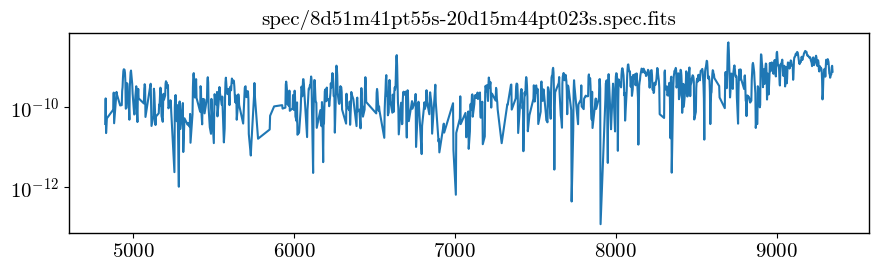

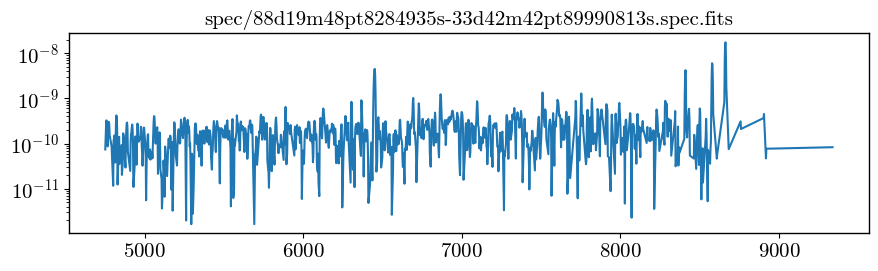

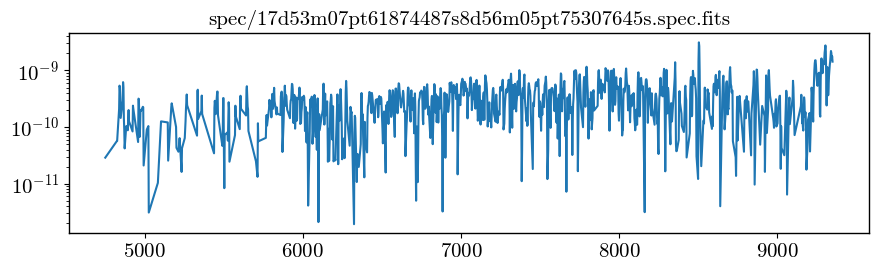

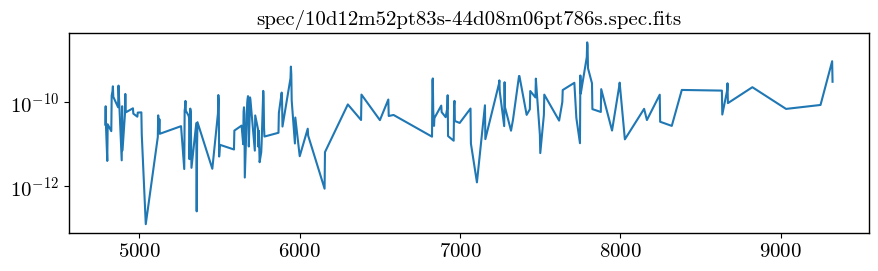

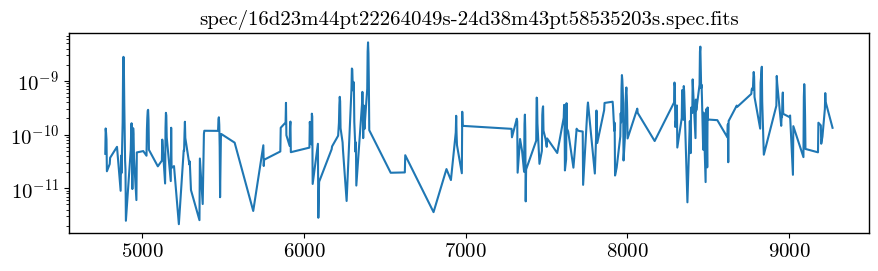

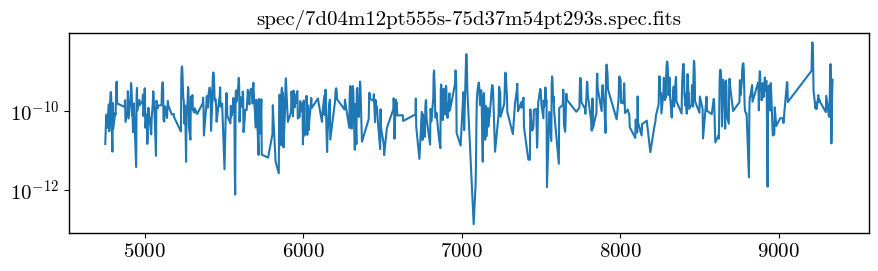

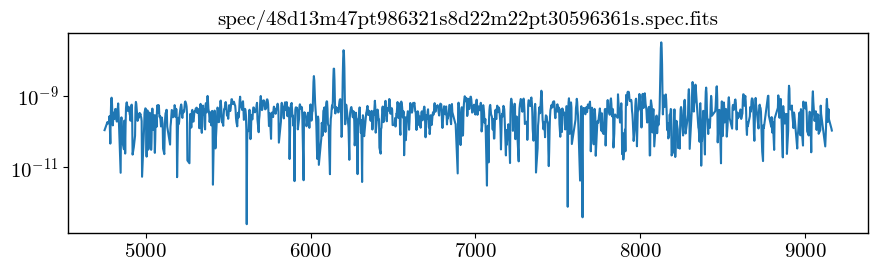

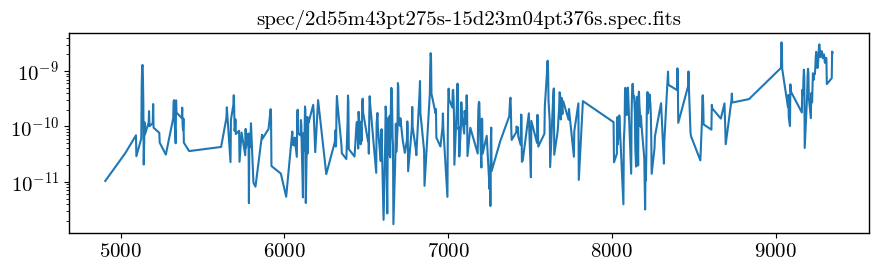

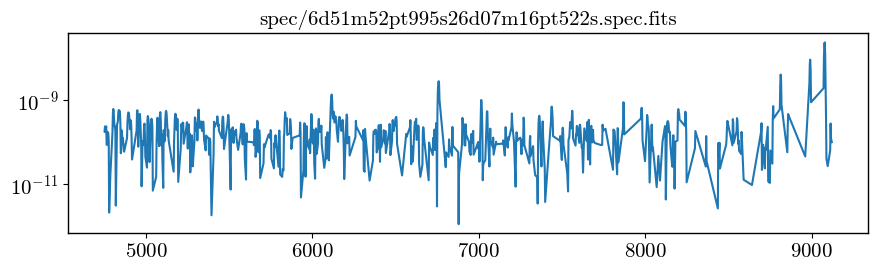

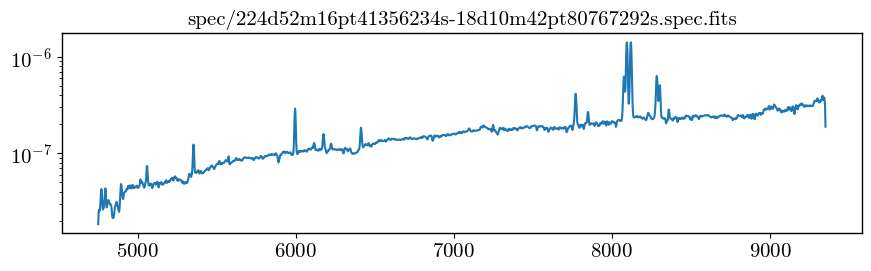

In [18]:
list = glob('spec/*.fits')
for l in list:
    print(l)

    table = Table(fits.open(l)[1].data)

    mask = table['flux_maggie']>0

    fig, ax = pf.create_plot((8,2))
    ax.semilogy(table['wavelength'][mask], table['flux_maggie'][mask])
    ax.set_title(l)

    ax.plot()

In [19]:
table

wavelength,flux_maggie
float64,float64
4750.998046875,1.832915241921547e-08
4753.498046875,2.3837556678756682e-08
4755.998046875,2.5861264722024725e-08
4758.498046875,2.5845045673378063e-08
4760.998046875,2.5289069379752347e-08
4763.498046875,2.795362692216904e-08
4765.998046875,3.3251500952077723e-08
4768.498046875,3.9319268359707565e-08
4770.998046875,4.259135647498042e-08
